# Can you trust a brain-reading AI? A hands-on investigation

### (built to be read top-to-bottom by a curious high-schooler)

**The big question.** People build AI that reads brain signals (EEG) to tell what you're
imagining — for example *"left hand"* vs *"right hand."* Before trusting such an AI, scientists
run **"controls"**: they deliberately damage the brain signal in a targeted way and check whether
the AI gets worse. If it does, they say *"good — the AI really relies on the brain signal."*

**The catch nobody checked:** do those controls actually work? A control that stays silent when it
should shout would give false confidence. **This notebook builds a tiny fake brain where we KNOW
the truth, and tests whether the controls tell the truth.**

**How to read this notebook.** It is split into short, mostly independent sections. Each has a
plain-English explanation, then a small block of code, then a picture. You do **not** need to
understand every line of code — read the words, run the cell, look at the figure.

> Everything here runs on a normal laptop in a couple of minutes. No special hardware. No internet.

## 1. Setup

We only use standard scientific-Python tools: `numpy` (math), `scipy` (signal processing),
`matplotlib` (plots), and `scikit-learn` (simple machine learning). Run this once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft, rfftfreq
from scipy.signal import butter, filtfilt, welch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(0)
print("Ready. All tools loaded.")

Ready. All tools loaded.


## 2. Crash course: what is EEG?

Your brain cells fire tiny electrical signals. **EEG** (electroencephalography) records those as
tiny voltage wiggles using metal discs (**electrodes** / **channels**) placed on the scalp.

Three things to know:

1. **Many channels.** Each electrode sits over a different part of the head. Electrodes over the
   **motor** area (top-middle of the head, called C3 / Cz / C4) pick up movement-related activity.
   Electrodes at the **back** (occipital, O1 / Oz / O2) mostly see vision. Electrodes at the
   **front** (frontal, F3 / Fz / F4) often catch eye-blinks.
2. **Brain rhythms.** The wiggles contain repeating waves at different speeds (frequencies).
   The **mu rhythm** (~8–12 waves per second) over the motor area gets *weaker* when you imagine
   moving a hand. That change is what motor-imagery AIs try to read.
3. **Left/right flip.** Your **left** brain controls your **right** hand and vice-versa. So imagining
   the **right** hand changes the mu rhythm mostly on the **left** side of the head (channel C3).
   This left-vs-right imbalance is the real clue.

The next sections build a small fake version of exactly this, so we always know the true answer.

## 3. The electrode layout (montage)

We lay out 19 electrodes in a rough map of the head and tag each one as **motor**, **occipital**,
**frontal**, or **other**. The coordinates are just for drawing.

In [2]:
# name: (x, y) position for drawing, and which region it belongs to
CHANNELS = {
    "F3": (-0.40, 0.72, "frontal"),  "Fz": (0.00, 0.80, "frontal"),  "F4": (0.40, 0.72, "frontal"),
    "FC3":(-0.42, 0.36, "motor"),                                      "FC4":(0.42, 0.36, "motor"),
    "T7": (-0.85, 0.00, "other"),    "C3": (-0.50, 0.00, "motor"),    "Cz": (0.00, 0.00, "motor"),
    "C4": (0.50, 0.00, "motor"),     "T8": (0.85, 0.00, "other"),
    "CP3":(-0.42,-0.36, "motor"),                                      "CP4":(0.42,-0.36, "motor"),
    "P3": (-0.40,-0.62, "other"),    "Pz": (0.00,-0.66, "other"),     "P4": (0.40,-0.62, "other"),
    "PO3":(-0.30,-0.82, "occipital"),                                  "PO4":(0.30,-0.82, "occipital"),
    "O1": (-0.20,-0.93, "occipital"),                                  "O2": (0.20,-0.93, "occipital"),
}
CH_NAMES = list(CHANNELS.keys())
N_CH = len(CH_NAMES)
REGION = {n: CHANNELS[n][2] for n in CH_NAMES}

# handy index lists we will reuse
def idx_where(region):        return [i for i,n in enumerate(CH_NAMES) if REGION[n]==region]
MOTOR      = idx_where("motor")
OCCIPITAL  = idx_where("occipital")
FRONTAL    = idx_where("frontal")
# left / right motor channels (left hemisphere names end in odd number: C3, FC3, CP3)
LEFT_MOTOR  = [i for i in MOTOR if CH_NAMES[i][-1] in "13"]
RIGHT_MOTOR = [i for i in MOTOR if CH_NAMES[i][-1] in "24"]
print(f"{N_CH} channels. motor={[CH_NAMES[i] for i in MOTOR]}")
print(f"left-motor={[CH_NAMES[i] for i in LEFT_MOTOR]}  right-motor={[CH_NAMES[i] for i in RIGHT_MOTOR]}")

19 channels. motor=['FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4']
left-motor=['FC3', 'C3', 'CP3']  right-motor=['FC4', 'C4', 'CP4']


### Figure 1 — where the electrodes sit
Colour = region. Remember: **motor** (orange) is where the hand-imagery signal lives;
**occipital** (green) and **frontal** (blue) are "control" areas that should NOT carry the signal.

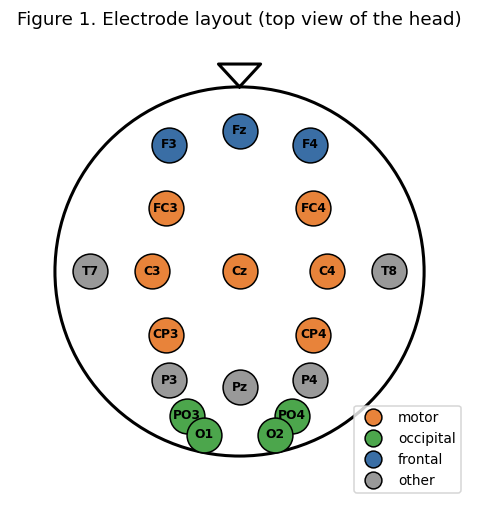

In [3]:
colors = {"motor":"#E8833A", "occipital":"#4CA64C", "frontal":"#3A6EA5", "other":"#999999"}
fig, ax = plt.subplots(figsize=(5.5,5.5))
head = plt.Circle((0,0), 1.05, fill=False, lw=2, color="k"); ax.add_patch(head)
ax.plot([0,-0.12,0.12,0],[1.05,1.18,1.18,1.05], color="k", lw=2)  # nose
for n,(x,y,r) in CHANNELS.items():
    ax.scatter(x,y,s=520, color=colors[r], edgecolor="k", zorder=3)
    ax.text(x,y,n, ha="center", va="center", fontsize=8, fontweight="bold", zorder=4)
handles=[plt.Line2D([0],[0],marker="o",ls="",mfc=c,mec="k",ms=11,label=r) for r,c in colors.items()]
ax.legend(handles=handles, loc="lower right", fontsize=9)
ax.set_title("Figure 1. Electrode layout (top view of the head)")
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.35); ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 4. What does the data actually look like?

One **trial** = one moment where the person imagines a hand. For each trial we record every channel
for a short time. So one trial is a grid of numbers: **channels × time-points**.

- Sampling rate `FS = 128`: we measure 128 times per second.
- Each trial is 2 seconds long → `256` time-points.
- A full dataset is many trials: **trials × channels × time**.

These are the three numbers you will see everywhere in EEG.

In [4]:
FS       = 128          # samples per second
DURATION = 2.0          # seconds per trial
N_TIME   = int(FS*DURATION)   # 256 time-points
TIME     = np.arange(N_TIME)/FS
print(f"One trial = {N_CH} channels x {N_TIME} time-points ({DURATION}s at {FS} Hz)")

One trial = 19 channels x 256 time-points (2.0s at 128 Hz)


## 5. Building a tiny fake brain (the simulator)

Why fake it? Because with real brains we never know the *true* answer, so we can't grade the
controls. In our simulator **we decide the truth**, so later we can check who got it right.

Each fake trial is made of two ingredients:

1. **Background "brain noise"** — realistic random wiggles on every channel (called *pink noise*:
   slow waves are stronger than fast ones, like real EEG).
2. **The planted signal** — a **10 Hz mu-rhythm burst** added only to the **motor** channels,
   on the side **opposite** the imagined hand (right hand → left-motor channels). Its `strength`
   is a knob we control. `strength = 0` means *no signal at all*.

That's it. Simple, but it captures the real clue: a left-vs-right imbalance of mu rhythm over motor cortex.

In [5]:
def pink_noise(n_ch, n_time, rng):
    "Random EEG-like background: more power at low frequencies (1/f)."
    freqs = rfftfreq(n_time, 1/FS)
    scale = np.ones_like(freqs); scale[1:] = 1/np.sqrt(freqs[1:])
    spec = (rng.standard_normal((n_ch, freqs.size)) + 1j*rng.standard_normal((n_ch, freqs.size))) * scale
    x = irfft(spec, n=n_time, axis=1)
    return x / (x.std(axis=1, keepdims=True) + 1e-9)   # unit size per channel

def make_trial(label, strength, rng):
    "label 1 = right hand (signal on LEFT motor); label 0 = left hand (signal on RIGHT motor)."
    x = pink_noise(N_CH, N_TIME, rng)
    window = np.hanning(N_TIME)                       # smooth fade in/out
    burst  = strength * np.sin(2*np.pi*10*TIME) * window   # a 10 Hz mu burst
    target = LEFT_MOTOR if label==1 else RIGHT_MOTOR
    for ch in target:
        x[ch] += burst
    return x

def make_dataset(n_per_class, strength, seed):
    "Return X = [trials, channels, time] and y = labels (0/1)."
    rng = np.random.default_rng(seed)
    X, y = [], []
    for label in (0, 1):
        for _ in range(n_per_class):
            X.append(make_trial(label, strength, rng)); y.append(label)
    return np.array(X), np.array(y)

X_demo, y_demo = make_dataset(n_per_class=40, strength=1.0, seed=1)
print("dataset shape (trials, channels, time):", X_demo.shape)

dataset shape (trials, channels, time): (80, 19, 256)


### Figure 2 — a few raw channels from one trial
This is what a slice of EEG looks like: just wiggly lines. The signal is hidden inside — you can't
see it by eye, which is exactly why we need controls and math.

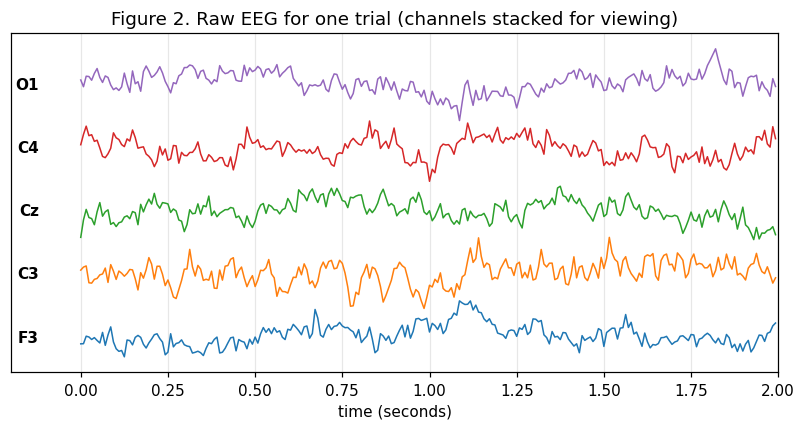

In [6]:
trial = X_demo[y_demo==1][0]   # a "right hand" trial
show = ["F3","C3","Cz","C4","O1"]
fig, ax = plt.subplots(figsize=(9,4))
for k,name in enumerate(show):
    ci = CH_NAMES.index(name)
    ax.plot(TIME, trial[ci] + k*6, lw=1)     # +offset so lines don't overlap
    ax.text(-0.12, k*6, name, ha="right", va="center", fontweight="bold")
ax.set_xlabel("time (seconds)"); ax.set_yticks([]); ax.set_xlim(-0.2, DURATION)
ax.set_title("Figure 2. Raw EEG for one trial (channels stacked for viewing)")
plt.show()

## 6. Seeing rhythms: the frequency view

A wiggly line can be re-described as *"how much of each rhythm speed is inside it."* That is the
**power spectrum**. Slow waves = low frequency (left), fast waves = high frequency (right).

We care about two bands:
- **mu band (8–12 Hz)** — where our motor signal lives.
- **beta band (16–28 Hz)** — a faster band we will use as a *control* (no signal there).

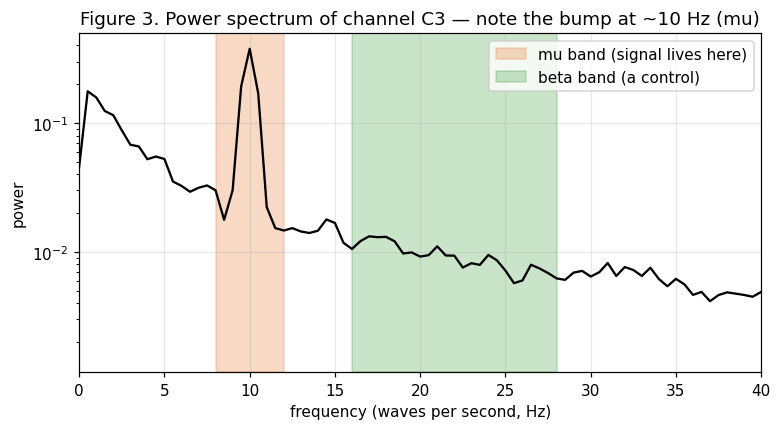

In [7]:
MU   = (8, 12)
BETA = (16, 28)
ci = CH_NAMES.index("C3")
f, Pxx = welch(X_demo[y_demo==1][:,ci,:], fs=FS, nperseg=N_TIME, axis=1)
fig, ax = plt.subplots(figsize=(8,4))
ax.semilogy(f, Pxx.mean(0), color="k")
ax.axvspan(*MU,   color="#E8833A", alpha=0.3, label="mu band (signal lives here)")
ax.axvspan(*BETA, color="#4CA64C", alpha=0.3, label="beta band (a control)")
ax.set_xlim(0,40); ax.set_xlabel("frequency (waves per second, Hz)"); ax.set_ylabel("power")
ax.set_title("Figure 3. Power spectrum of channel C3 — note the bump at ~10 Hz (mu)")
ax.legend(); plt.show()

## 7. Preprocessing: cleaning the data before analysis

Real EEG is messy, so scientists **preprocess** every trial the same way before doing anything.
The most important step is **band-pass filtering**: keep only the frequencies we care about
(here 4–30 Hz) and throw away very slow drifts and very fast noise. Below we filter one channel and
plot before/after so you can *see* what filtering does.

*(Other standard steps, not shown here for simplicity: re-referencing all channels to their average,
resampling to a common rate, and cutting the recording into fixed 2-second trials — "epoching".)*

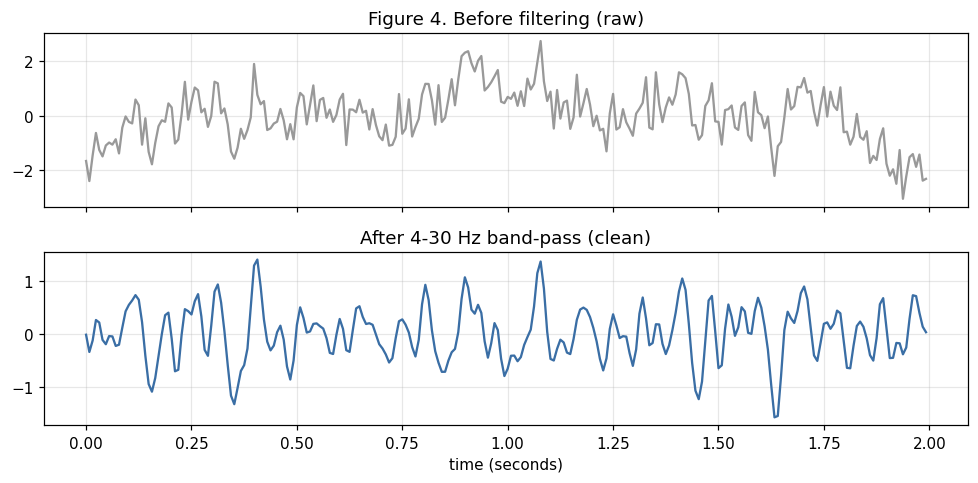

In [8]:
def bandpass(x, lo=4, hi=30):
    b, a = butter(4, [lo/(FS/2), hi/(FS/2)], btype="band")
    return filtfilt(b, a, x)

raw  = X_demo[0, CH_NAMES.index("C3")]
clean = bandpass(raw)
fig, ax = plt.subplots(2,1, figsize=(9,4.5), sharex=True)
ax[0].plot(TIME, raw, color="#999"); ax[0].set_title("Figure 4. Before filtering (raw)")
ax[1].plot(TIME, clean, color="#3A6EA5"); ax[1].set_title("After 4-30 Hz band-pass (clean)")
ax[1].set_xlabel("time (seconds)")
plt.tight_layout(); plt.show()

## 8. The ground truth we planted (why simulation is powerful)

Because *we* built the data, we know exactly where the signal is: a mu-rhythm imbalance across the
**left vs right motor** channels. Let's confirm it by measuring **mu power** in each channel,
averaged separately for "left hand" and "right hand" trials. The motor channels should light up in
**opposite** directions for the two classes; everything else should look the same.

This "topographic" picture is the kind of figure that goes in a paper — it shows the effect is real
and located where we claim.

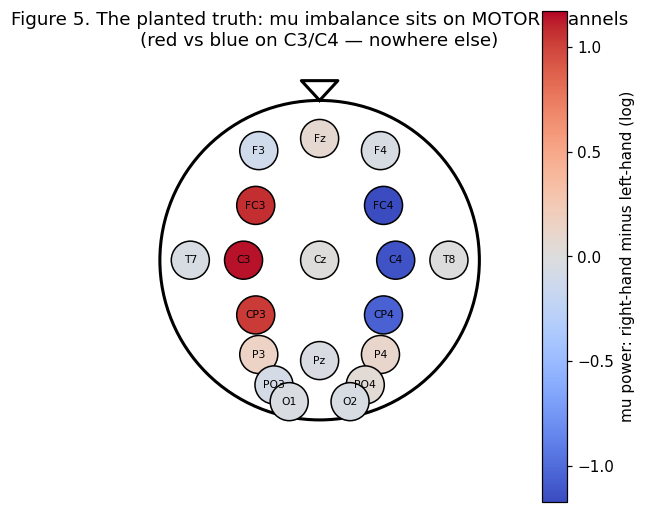

In [9]:
def mu_power_per_channel(X):
    "Average mu-band power for each channel, per trial."
    F = rfft(X, axis=2); freqs = rfftfreq(N_TIME, 1/FS)
    m = (freqs>=MU[0]) & (freqs<=MU[1])
    return (np.abs(F[:,:,m])**2).mean(axis=2)      # [trials, channels]

P = mu_power_per_channel(X_demo)
left_hand  = P[y_demo==0].mean(0)     # class 0
right_hand = P[y_demo==1].mean(0)     # class 1
diff = np.log(right_hand+1e-9) - np.log(left_hand+1e-9)   # right minus left, per channel

fig, ax = plt.subplots(figsize=(5.8,5.8))
head = plt.Circle((0,0),1.05,fill=False,lw=2,color="k"); ax.add_patch(head)
ax.plot([0,-0.12,0.12,0],[1.05,1.18,1.18,1.05],color="k",lw=2)
vmax = np.abs(diff).max()
sc = ax.scatter([CHANNELS[n][0] for n in CH_NAMES],[CHANNELS[n][1] for n in CH_NAMES],
                s=620, c=diff, cmap="coolwarm", vmin=-vmax, vmax=vmax, edgecolor="k", zorder=3)
for n in CH_NAMES:
    ax.text(CHANNELS[n][0],CHANNELS[n][1],n,ha="center",va="center",fontsize=7,zorder=4)
plt.colorbar(sc,label="mu power: right-hand minus left-hand (log)")
ax.set_title("Figure 5. The planted truth: mu imbalance sits on MOTOR channels\n(red vs blue on C3/C4 — nowhere else)")
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.35); ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 9. Building two "mind-reader" AIs

A mind-reader here is just a simple classifier that looks at **features** (numbers summarizing a
trial) and guesses left vs right. We build **two** on purpose, because the whole punchline is that
*they behave differently.*

- **Focused AI** — looks at only **two numbers**: the mu power on the left-motor channels and on
  the right-motor channels. It looks *exactly* where the signal is. *(a linear model)*
- **Broad AI** — looks at **every channel** in both the mu and beta bands (many numbers). It doesn't
  know where to look, so it uses everything. *(also linear)*
- **Tree AI** — sees the **same many numbers as the Broad AI**, but it is a *different kind* of model:
  a **random forest** (a bunch of decision trees). A tree only *uses* the numbers it finds useful and
  ignores the rest — so it can look broadly but still be selective.

The first two are logistic regression; the third is a random forest. Keep an eye on **Broad vs Tree**
later — they see identical features but behave very differently.

In [10]:
from sklearn.ensemble import RandomForestClassifier

def band_power(X, band):
    F = rfft(X, axis=2); freqs = rfftfreq(N_TIME, 1/FS)
    m = (freqs>=band[0]) & (freqs<=band[1])
    return np.log((np.abs(F[:,:,m])**2).mean(axis=2) + 1e-12)   # [trials, channels]

def features_focused(X):
    mu = band_power(X, MU)
    return np.stack([mu[:,LEFT_MOTOR].mean(1), mu[:,RIGHT_MOTOR].mean(1)], axis=1)   # 2 features

def features_broad(X):
    return np.concatenate([band_power(X, MU), band_power(X, BETA)], axis=1)          # many features

def new_lr():   return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
def new_tree(): return RandomForestClassifier(n_estimators=200, random_state=0)

# each AI = (name, which features it sees, what KIND of model it is)
AIS = [("Focused", features_focused, new_lr),     # linear · looks only where the signal is
       ("Broad",   features_broad,   new_lr),     # linear · looks everywhere
       ("Tree",    features_broad,   new_tree)]    # random forest · looks everywhere, but selectively

for name, feat, _ in AIS:
    print(f"{name:8s} AI: {feat(X_demo).shape[1]} features")

Focused  AI: 2 features
Broad    AI: 38 features
Tree     AI: 38 features


## 10. Sanity check: do the AIs work at all?

Before testing controls, we must confirm the AIs actually learn. We test two situations:

- **Signal present** (`strength = 1`): a real mu imbalance exists → the AI should score well above 50%.
- **Signal absent** (`strength = 0`): pure noise, nothing to learn → the AI should score ~50% (a
  coin-flip). If it scored high here, something would be leaking and the whole study would be invalid.

We always **train** on one set of trials and **test** on *different* trials — never grade an AI on
data it studied.

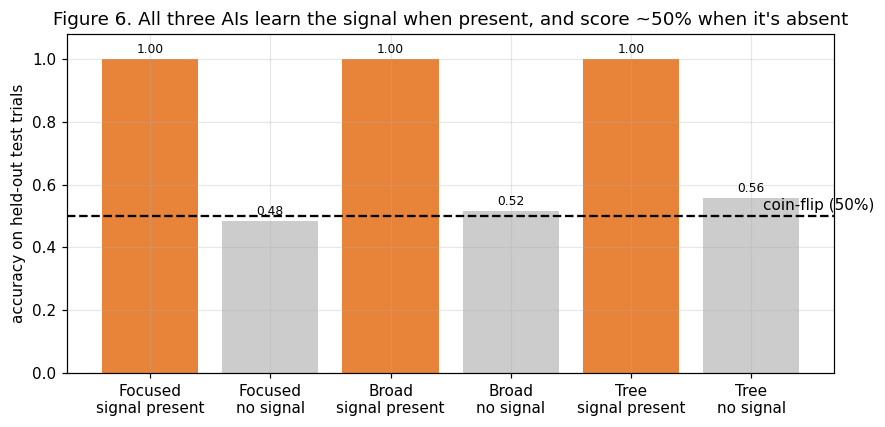

In [11]:
def train_and_score(features, factory, strength, seed=7):
    Xtr,ytr = make_dataset(60, strength, seed)       # training trials
    Xte,yte = make_dataset(60, strength, seed+999)   # fresh test trials
    ai = factory(); ai.fit(features(Xtr), ytr)
    return (ai.predict(features(Xte))==yte).mean()

res = {}
for name, feat, factory in AIS:
    res[(name,"signal present")] = train_and_score(feat, factory, 1.0)
    res[(name,"no signal")]      = train_and_score(feat, factory, 0.0)

labels = list(res.keys()); vals=[res[k] for k in labels]
fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar([f"{a}\n{b}" for a,b in labels], vals, color=["#E8833A","#ccc"]*len(AIS))
ax.axhline(0.5, ls="--", color="k"); ax.text(len(vals)-0.9,0.52,"coin-flip (50%)")
ax.set_ylim(0,1.08); ax.set_ylabel("accuracy on held-out test trials")
ax.set_title("Figure 6. All three AIs learn the signal when present, and score ~50% when it's absent")
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=8)
plt.show()

## 11. The controls (perturbations)

To argue an AI *uses* the brain signal, scientists damage the input and watch accuracy. Each way of
damaging is a **control**, and each control is *supposed* to test one specific thing:

- **remove_mu** — erase the mu band. Should hurt (signal lives in mu).
- **remove_motor** — silence the motor channels. Should hurt (signal lives there).
- **remove_beta** — erase the beta band. Should NOT hurt (no signal there) → a good control stays quiet.
- **remove_occipital** — silence the back-of-head channels. Should NOT hurt → should stay quiet.

The last two are the important test: a trustworthy control must stay *quiet* when its target is absent.

In [12]:
def remove_band(X, band):
    "Erase a frequency band (set its content to zero) -- the intuitive meaning of 'remove'."
    F = rfft(X, axis=2); freqs = rfftfreq(N_TIME, 1/FS)
    m = (freqs>=band[0]) & (freqs<=band[1]); F[:,:,m]=0.0
    return irfft(F, n=N_TIME, axis=2)

def silence_channels(X, idx):
    X2 = X.copy(); X2[:, idx, :] = 0.0; return X2

CONTROLS = {
    "remove_mu":        lambda X: remove_band(X, MU),
    "remove_motor":     lambda X: silence_channels(X, MOTOR),
    "remove_beta":      lambda X: remove_band(X, BETA),
    "remove_occipital": lambda X: silence_channels(X, OCCIPITAL),
}
print("controls:", list(CONTROLS))

controls: ['remove_mu', 'remove_motor', 'remove_beta', 'remove_occipital']


### Figure 7 — what each control does to the signal
Same channel (C3), before vs after each control. `remove_mu` flattens the 10 Hz bump;
`remove_beta` flattens a different part; the channel-silencing controls set whole electrodes to zero.

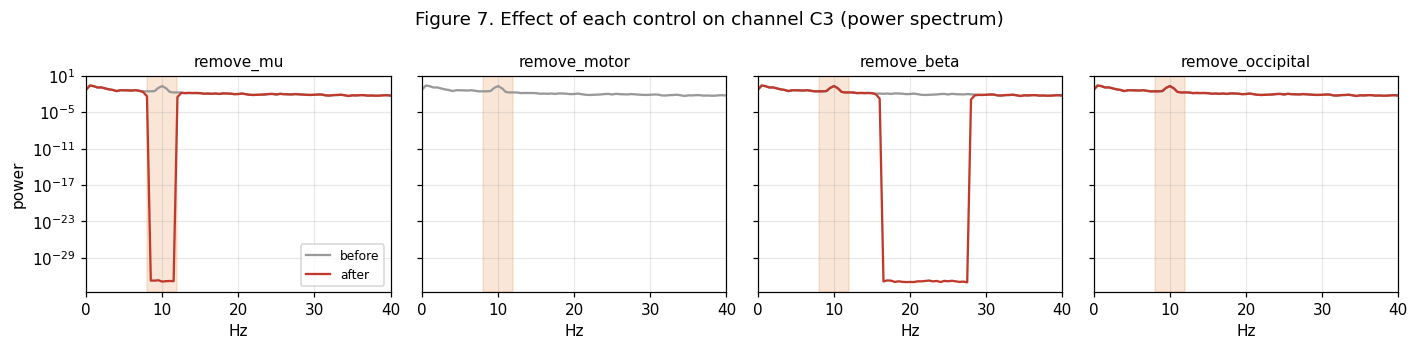

In [13]:
one,_ = make_dataset(30, 1.0, seed=3)
ci = CH_NAMES.index("C3")
fig, axes = plt.subplots(1,4, figsize=(13,3.2), sharey=True)
for ax,(nm,fn) in zip(axes, CONTROLS.items()):
    f0,P0 = welch(one[:,ci,:], fs=FS, nperseg=N_TIME, axis=1)
    f1,P1 = welch(fn(one)[:,ci,:], fs=FS, nperseg=N_TIME, axis=1)
    ax.semilogy(f0,P0.mean(0),color="#999",label="before")
    ax.semilogy(f1,P1.mean(0),color="#c0392b",label="after")
    ax.axvspan(*MU,color="#E8833A",alpha=.2); ax.set_xlim(0,40); ax.set_title(nm,fontsize=10)
    ax.set_xlabel("Hz")
axes[0].set_ylabel("power"); axes[0].legend(fontsize=8)
plt.suptitle("Figure 7. Effect of each control on channel C3 (power spectrum)")
plt.tight_layout(); plt.show()

## 12. The experiment: do the controls tell the truth?

Plan: plant the signal in **motor-mu** (we know the truth). Train each AI. Then apply each control to
the test trials and measure the **accuracy drop**. We call a control **"fires"** if it drops accuracy
by more than 10 points.

Two things a control can get wrong:
- **Miss** — the target IS present but the control stays quiet (a false *negative*).
- **False alarm** — the target is ABSENT but the control fires anyway (a false *positive*).

We repeat over 15 random datasets and report, for each control, **how often it fires**.

In [14]:
def drop_for_control(features, factory, control_fn, seed):
    Xtr,ytr = make_dataset(60, 1.0, seed)          # signal is in motor-mu
    Xte,yte = make_dataset(60, 1.0, seed+999)
    ai = factory(); ai.fit(features(Xtr), ytr)
    base = (ai.predict(features(Xte))==yte).mean()
    hit  = (ai.predict(features(control_fn(Xte)))==yte).mean()
    return base - hit

SEEDS = range(15)
FIRE_THRESHOLD = 0.10
fire_rate = {}   # (ai_name, control) -> fraction of datasets where it fired
for ai_name, feat, factory in AIS:
    for cname, cfn in CONTROLS.items():
        drops = [drop_for_control(feat, factory, cfn, s) for s in SEEDS]
        fire_rate[(ai_name,cname)] = np.mean([d > FIRE_THRESHOLD for d in drops])
print(f"done — fire rates for {len(AIS)} AIs x {len(CONTROLS)} controls x {len(list(SEEDS))} datasets")

done — fire rates for 3 AIs x 4 controls x 15 datasets


### Figure 8 — the main result
Left panel = controls whose target **is** present (they *should* fire — green good).
Right panel = controls whose target is **absent** (they *should stay quiet* — red = false alarm, bad).
Watch the **Broad** AI light up red on the right (it cries wolf) — while the **Tree** AI, which sees the
*same* features, stays clean.

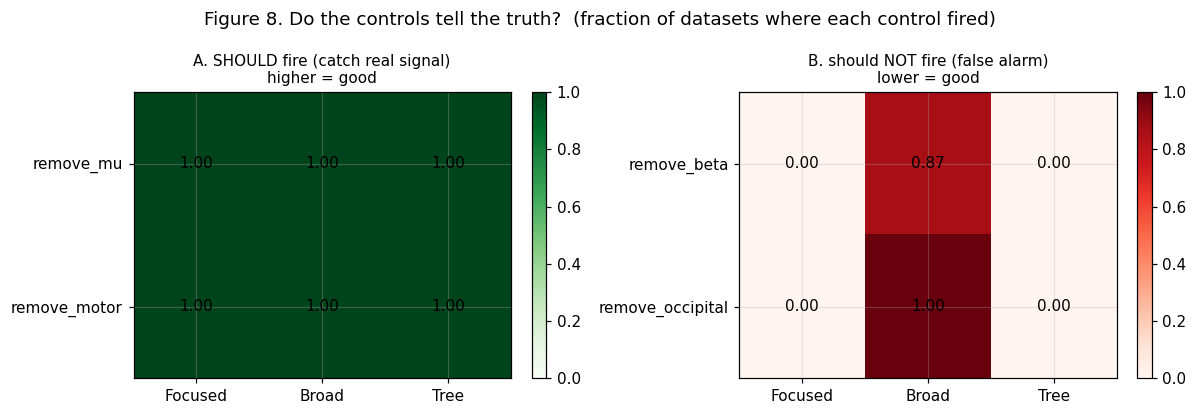

In [15]:
should_fire   = ["remove_mu","remove_motor"]       # target present
shouldnt_fire = ["remove_beta","remove_occipital"] # target absent
ais = ["Focused","Broad","Tree"]

def grid(controls): return np.array([[fire_rate[(ai,c)] for ai in ais] for c in controls])
GA, GB = grid(should_fire), grid(shouldnt_fire)

fig, axs = plt.subplots(1,2, figsize=(11,3.8))
for ax,G,rows,title,cmap in [
    (axs[0],GA,should_fire,"A. SHOULD fire (catch real signal)\nhigher = good","Greens"),
    (axs[1],GB,shouldnt_fire,"B. should NOT fire (false alarm)\nlower = good","Reds")]:
    im=ax.imshow(G,vmin=0,vmax=1,cmap=cmap,aspect="auto")
    ax.set_xticks(range(len(ais))); ax.set_xticklabels(ais)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
    for i in range(G.shape[0]):
        for j in range(G.shape[1]): ax.text(j,i,f"{G[i,j]:.2f}",ha="center",va="center")
    ax.set_title(title, fontsize=10); fig.colorbar(im,ax=ax,fraction=0.046)
plt.suptitle("Figure 8. Do the controls tell the truth?  (fraction of datasets where each control fired)")
plt.tight_layout(); plt.show()

## 13. What just happened — the punchline

- **All three AIs catch the real signal** (left panel green): remove the mu rhythm or silence the
  motor channels and every one gets worse. Good.
- **But the Broad AI cries wolf** (right panel): it *also* gets worse when you remove **beta** or
  silence the **occipital** channels — places with **no signal at all**. The **Focused** and **Tree**
  AIs stay calm.

Why does Broad cry wolf but Tree doesn't, when they see the **exact same features**? The Broad AI is
*linear* — it weighs **every** feature, so **any** tampering shifts its numbers. The Tree only *splits
on* the handful of features it actually needs (mu-motor) and ignores the rest, so zeroing an unrelated
band or region barely moves it. **Same information, different *kind* of model → different reliability.**

**The lesson:** whether you can trust a control depends on **which AI** you are testing — not just how
*narrowly* it looks, but what *kind* of model it is. A positive control result can be strong evidence
for one model and near-meaningless for another.

# Part II — The research project

Everything above was a small, self-contained demo built for clarity. The rest of the notebook is the
**actual research study** this demo is based on: the same idea, done at full scale on real human brain
data, with the parts that make it a genuine scientific contribution.

## 14. What is new here (the contribution)

Perturbation "controls" have been used for years to argue an EEG decoder relies on real brain signal.
Whole papers rest on them. **But no one had measured whether the controls themselves are reliable** —
their miss rates and false-alarm rates were simply unknown. A test you never validated is not evidence.

**Our contribution is a *validated measuring instrument*, not a new decoder:**

1. A controllable **MI-EEG simulator** with known ground truth (we choose the band, region, timing, and
   strength of the class signal, and can inject confounds).
2. **Operating characteristics for every control** — its catch rate (sensitivity) and false-alarm rate
   (specificity) — measured against that ground truth across a grid of conditions and three decoders.
3. A **calibrated audit of real decoders**: we run the controls on real PhysioNet / BCI-IV data and
   report each neural-dependence conclusion *weighted by that control's measured reliability*.

**Where it sits in the literature (and an honest novelty statement).**

| Prior work | What they did | What we add |
|---|---|---|
| Perturbation / ablation EEG audits | *Use* controls as trusted evidence | **Measure whether the controls are valid** |
| Explainability-vs-simulation (Sci Rep 2023) | Validate *saliency* methods vs simulated truth | Validate *perturbation-based* neural-dependence controls |
| EEG fragility / leakage papers | Show decoders are fragile & confounded | Provide a *calibrated instrument* to detect it |

Honestly stated: the individual controls are not new, and validating-against-simulation is an
established idea in other settings. The novelty is the **specific, unfilled combination** — calibrating
perturbation neural-dependence controls for EEG motor-imagery against ground truth — and the resulting
**cautionary finding** that popular controls can be untrustworthy in ways that depend on the decoder.

## 15. The full-scale study: data and methods

- **Real EEG:** PhysioNet EEGMMIDB (**109 people**) and the independent BCI Competition IV-2a dataset.
  Standard preprocessing (average reference, 4–40 Hz band-pass, 160 Hz, 0.5–3.0 s imagery window), with
  **participant-held-out** evaluation — every person the decoder is tested on is someone it never trained on.
- **Three real decoders:** band-power + logistic regression, CSP + LDA (a classic spatial filter), and
  **EEGNet** (a compact neural network).
- **The simulator at scale:** the same idea as our toy, but on the real 64-channel head layout, sweeping
  **50 ground-truth conditions** (rhythm × region × signal-strength × confound × two signal types), each
  with 5 network re-trainings.
- **Calibrate, then apply:** measure each control's catch/false-alarm rate on the simulator (where truth
  is known), then carry those numbers over to interpret the real decoders. A control is only graded on a
  decoder that actually learned the planted signal (a "decodability floor").

*(The heavy pipeline — real-data download, training, and the 50-condition grid — lives in the research
notebook `eeg_neural_dependence_complete.ipynb`. Its measured results are **embedded as data below**, so
this single notebook stands alone: download just this file and it reproduces every figure.)*

In [16]:
# ---------- Publication setup: styling, embedded real results, and figure helpers ----------
import pandas as pd
from pathlib import Path
from scipy.interpolate import Rbf
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

plt.rcParams.update({"font.size":9, "axes.titlesize":10, "axes.titleweight":"bold", "axes.labelsize":9,
    "axes.spines.top":False, "axes.spines.right":False, "axes.grid":False, "savefig.dpi":300})
PAPER = Path("paper_figures"); PAPER.mkdir(exist_ok=True)
def save_paper(fig, name):                       # writes a vector PDF + a 300-dpi PNG
    fig.savefig(PAPER/f"{name}.pdf", bbox_inches="tight"); fig.savefig(PAPER/f"{name}.png", dpi=300, bbox_inches="tight")

# ---- REAL measured numbers from the full-scale study (embedded so this file is self-contained) ----
PROBES = ["remove_mu","remove_beta","remove_mu_beta","remove_sensorimotor","remove_occipital_control","remove_theta","remove_high_control"]
PROBE_LABEL = {"remove_mu":"Remove μ band","remove_beta":"Remove β band","remove_mu_beta":"Remove μ+β",
    "remove_sensorimotor":"Remove sensorimotor","remove_occipital_control":"Remove occipital",
    "remove_theta":"Remove θ band","remove_high_control":"Remove 31–40 Hz"}
DECODERS = ["bandpower","csp","tree","eegnet"]
DECODER_LABEL = {"bandpower":"Band-power","csp":"CSP","tree":"Tree (RF)","eegnet":"EEGNet"}
nan = np.nan
# sensitivity (catch rate) and false-alarm rate, per control x decoder, measured on the simulator grid:
OC_CATCH = pd.DataFrame({"bandpower":[.92,.83,.92,1,1,nan,nan],"csp":[1,1,1,1,1,nan,nan],
                         "tree":[1,1,1,1,1,nan,nan],"eegnet":[1,1,1,1,1,nan,nan]}, index=PROBES)
OC_FALSE = pd.DataFrame({"bandpower":[.67,.67,nan,.83,.67,.58,.71],"csp":[0,.08,nan,.73,.67,0,0],
                         "tree":[.75,.83,nan,.67,.33,.58,.62],"eegnet":[0,0,nan,0,0,.08,0]}, index=PROBES)
# held-out accuracy of the real decoders (balanced; 0.5 = chance):
REAL_ACC = pd.DataFrame({"bandpower":[.584,.584],"csp":[.617,.675],"eegnet":[.656,.733]}, index=["PhysioNet (109)","BCI-IV (9)"])
# calibrated audit on real PhysioNet decoders. category: 0 = trustworthy-uses, 1 = suspect, 2 = trustworthy-does-not-use
AUDIT_DECODERS = ["bandpower","csp","tree","eegnet"]
AUDIT_COLS = ["remove_mu","remove_beta","remove_sensorimotor","remove_occipital_control"]
AUDIT      = pd.DataFrame([[1,1,1,1],[0,2,1,1],[1,1,1,1],[0,2,0,2]], index=AUDIT_DECODERS, columns=AUDIT_COLS)
AUDIT_DROP = pd.DataFrame([[.03,.04,.08,.08],[.02,.01,.13,.07],[.04,.05,.05,.02],[.04,.01,.09,.01]], index=AUDIT_DECODERS, columns=AUDIT_COLS)

def topomap(ax, values, title, cmap="RdBu_r"):   # simple scalp map from scattered electrodes (no extra libraries)
    xs=np.array([CHANNELS[n][0] for n in CH_NAMES]); ys=np.array([CHANNELS[n][1] for n in CH_NAMES])
    rbf=Rbf(xs,ys,values,function="multiquadric",smooth=0.05)
    gx,gy=np.mgrid[-1.1:1.1:160j,-1.1:1.1:160j]; gz=rbf(gx,gy); gz[gx**2+gy**2>1.02**2]=np.nan
    v=np.nanmax(np.abs(values))
    im=ax.imshow(gz.T,extent=[-1.1,1.1,-1.1,1.1],origin="lower",cmap=cmap,vmin=-v,vmax=v)
    ax.contour(gx,gy,gz,levels=5,colors="k",linewidths=0.3)
    ax.add_patch(plt.Circle((0,0),1.0,fill=False,color="k",lw=1.5)); ax.plot([0,-.1,.1,0],[1,1.13,1.13,1],color="k",lw=1.5)
    ax.scatter(xs,ys,s=6,c="k")
    ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.25); ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title,loc="left")
    return im
print("Publication setup ready — real results embedded; paper figures will be saved to ./paper_figures/")

Publication setup ready — real results embedded; paper figures will be saved to ./paper_figures/


### Paper Figure 1 — the simulator testbed
The instrument rests on a simulator whose ground truth we set. Three panels: the electrode layout; the
planted signal (a μ bump appears only when we add it); and the ground-truth topography (the μ imbalance
sits on the motor channels — exactly where we placed it). *Generated live by this notebook.*

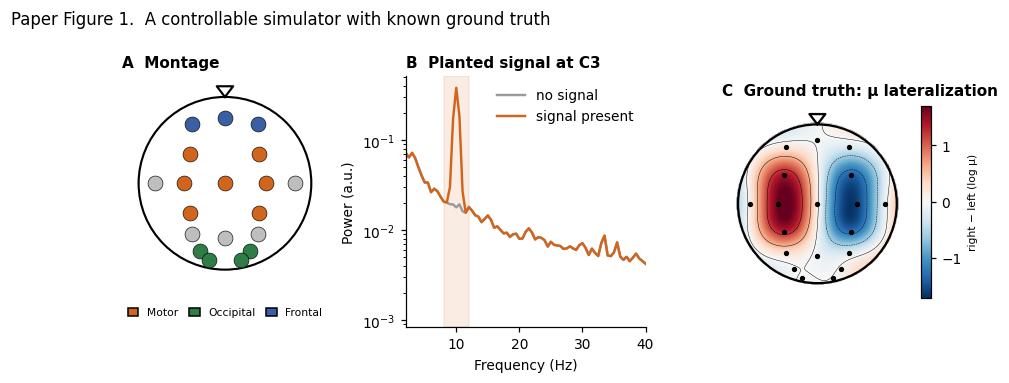

In [17]:
present, yb = make_dataset(n_per_class=40, strength=1.4, seed=11)
absent,  _  = make_dataset(n_per_class=40, strength=0.0, seed=11)
Pm = mu_power_per_channel(present)
gt = np.log(Pm[yb==1].mean(0)+1e-9) - np.log(Pm[yb==0].mean(0)+1e-9)

fig = plt.figure(figsize=(9.5,3.0)); gs=fig.add_gridspec(1,3,width_ratios=[1,1.15,1],wspace=0.35,top=0.80,bottom=0.04)
axA=fig.add_subplot(gs[0]); rc={"motor":"#D1651D","occipital":"#2E7D46","frontal":"#3B5FA4","other":"#BEBEBE"}
axA.add_patch(plt.Circle((0,0),1.05,fill=False,color="k",lw=1.4)); axA.plot([0,-.1,.1,0],[1.05,1.18,1.18,1.05],color="k",lw=1.4)
for n,(x,y,r) in CHANNELS.items(): axA.scatter(x,y,s=95,color=rc[r],edgecolor="k",lw=.4,zorder=3)
axA.set_xlim(-1.25,1.25); axA.set_ylim(-1.75,1.3); axA.set_aspect("equal"); axA.axis("off"); axA.set_title("A  Montage",loc="left")
axA.legend(handles=[Patch(facecolor=rc[k],edgecolor="k",label=k.title()) for k in ["motor","occipital","frontal"]],
           loc="lower center",bbox_to_anchor=(.5,0.0),frameon=False,fontsize=7,ncol=3,columnspacing=1,handlelength=1)
axB=fig.add_subplot(gs[1]); ci=CH_NAMES.index("C3")
for X,lab,c in [(absent,"no signal","#9a9a9a"),(present,"signal present","#D1651D")]:
    f,P=welch(X[:,ci,:],fs=FS,nperseg=N_TIME,axis=1); axB.semilogy(f,P.mean(0),color=c,lw=1.6,label=lab)
axB.axvspan(8,12,color="#D1651D",alpha=.12); axB.set_xlim(2,40); axB.set_xlabel("Frequency (Hz)"); axB.set_ylabel("Power (a.u.)")
axB.set_title("B  Planted signal at C3",loc="left"); axB.legend(frameon=False)
axC=fig.add_subplot(gs[2]); im=topomap(axC, gt, "C  Ground truth: μ lateralization")
fig.colorbar(im,ax=axC,fraction=.046,pad=.04).set_label("right − left (log μ)",fontsize=7)
fig.suptitle("Paper Figure 1.  A controllable simulator with known ground truth", x=.02,y=1.0,ha="left")
save_paper(fig,"figure1_simulator"); plt.show()

### Do the real decoders even work? (yes)
Before auditing controls we confirm the three real decoders actually read motor imagery on held-out people.

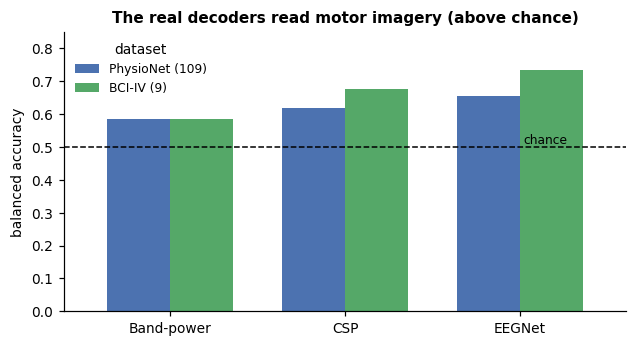

In [18]:
fig,ax=plt.subplots(figsize=(6.6,3.3))
REAL_ACC.T.plot.bar(ax=ax,color=["#4C72B0","#55A868"],rot=0,width=.72)
ax.axhline(.5,ls="--",color="k",lw=1); ax.text(2.02,.51,"chance",fontsize=8)
ax.set_ylim(0,.85); ax.set_ylabel("balanced accuracy"); ax.set_xlabel("")
ax.set_xticklabels([DECODER_LABEL[m] for m in REAL_ACC.columns]); ax.legend(title="dataset",frameon=False,fontsize=8)
ax.set_title("The real decoders read motor imagery (above chance)")
save_paper(fig,"figureS_accuracy"); plt.show()

## 16. Real result #1 — calibrating the controls (the instrument)

This is the core measurement, built on the simulator where we know the truth. For each control we ask
two things across all conditions and all three decoders:

- **Catch rate** (left): when the target signal really *is* present, does the control fire? (higher = better)
- **False-alarm rate** (right): when the target is *absent*, does the control fire anyway? (lower = better)

The result mirrors the toy exactly — but now measured, quantified, and paper-ready. The **band-power**
column glows red on the right: it fires under almost any perturbation, so its "evidence" is weak. The
**neural network** is the specific one.

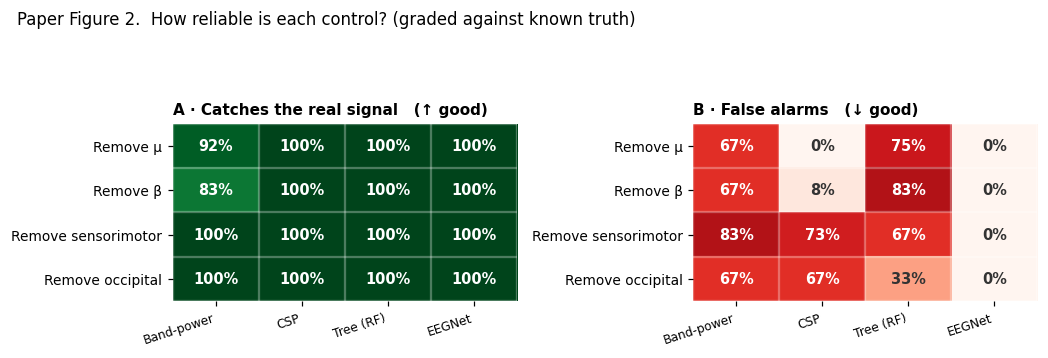

In [19]:
# show the four interpretable controls (each has both a catch and a false-alarm regime -> no empty cells)
CORE=["remove_mu","remove_beta","remove_sensorimotor","remove_occipital_control"]
CORE_LABEL={"remove_mu":"Remove μ","remove_beta":"Remove β","remove_sensorimotor":"Remove sensorimotor","remove_occipital_control":"Remove occipital"}
fig, axs = plt.subplots(1,2, figsize=(9.6,3.1))
def heatmap(ax, H, cmap, title):
    A=H.reindex(CORE)[DECODERS].values.astype(float)
    im=ax.imshow(A,vmin=0,vmax=1,cmap=cmap,aspect="auto")
    ax.set_xticks(range(len(DECODERS))); ax.set_xticklabels([DECODER_LABEL[m] for m in DECODERS], rotation=18, ha="right", fontsize=8)
    ax.set_yticks(range(len(CORE))); ax.set_yticklabels([CORE_LABEL[p] for p in CORE])
    ax.set_xticks(np.arange(-.5,len(DECODERS)),minor=True); ax.set_yticks(np.arange(-.5,len(CORE)),minor=True)
    ax.grid(which="minor",color="white",lw=1.5); ax.tick_params(which="minor",length=0)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            ax.text(j,i,f"{A[i,j]*100:.0f}%",ha="center",va="center",fontsize=9.5,fontweight="bold",
                    color="white" if (cmap=="Greens" and A[i,j]>.6) or (cmap=="Reds" and A[i,j]>.5) else "#333")
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(title,loc="left",fontsize=10); return im
heatmap(axs[0],OC_CATCH,"Greens","A · Catches the real signal   (↑ good)")
heatmap(axs[1],OC_FALSE,"Reds","B · False alarms   (↓ good)")
fig.suptitle("Paper Figure 2.  How reliable is each control? (graded against known truth)",x=.02,y=1.03,ha="left")
fig.tight_layout(rect=[0,0,1,.9]); save_paper(fig,"figure2_operating_characteristics"); plt.show()

## 17. Real result #2 — the calibrated audit of real decoders

Now we run the controls on the **real** PhysioNet decoders and attach each control's measured
reliability. That turns a bare "the control fired" into a trust-weighted statement. (BCI-IV is left out
here: with only 9 participants its test is underpowered — an honest limitation, not a result.)

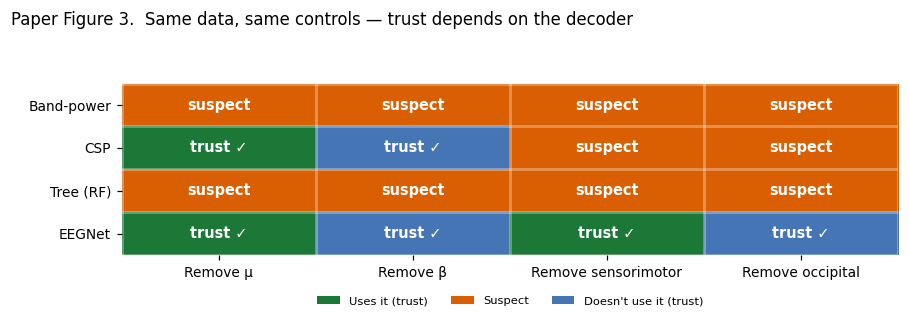

Table 2 — calibrated verdicts on real PhysioNet decoders:


,Remove μ,Remove β,Remove sensorimotor,Remove occipital
Band-power,SUSPECT (false-alarms) (Δacc=+0.03),SUSPECT (false-alarms) (Δacc=+0.04),SUSPECT (false-alarms) (Δacc=+0.08),SUSPECT (false-alarms) (Δacc=+0.08)
CSP,trustworthy: uses it (Δacc=+0.02),trustworthy: does not use it (Δacc=+0.01),SUSPECT (false-alarms) (Δacc=+0.13),SUSPECT (false-alarms) (Δacc=+0.07)
Tree (RF),SUSPECT (false-alarms) (Δacc=+0.04),SUSPECT (false-alarms) (Δacc=+0.05),SUSPECT (false-alarms) (Δacc=+0.05),SUSPECT (false-alarms) (Δacc=+0.02)
EEGNet,trustworthy: uses it (Δacc=+0.04),trustworthy: does not use it (Δacc=+0.01),trustworthy: uses it (Δacc=+0.09),trustworthy: does not use it (Δacc=+0.01)


In [20]:
CAT_COLORS=["#1B7837","#D95F02","#4575B4"]
CAT_LABEL=["Uses it (trust)","Suspect","Doesn't use it (trust)"]
SHORT_COL={"remove_mu":"Remove μ","remove_beta":"Remove β","remove_sensorimotor":"Remove sensorimotor","remove_occipital_control":"Remove occipital"}
M=AUDIT[AUDIT_COLS].values
fig,ax=plt.subplots(figsize=(8.4,3.0)); fig.subplots_adjust(top=.78,bottom=.26,left=.14,right=.98)
ax.imshow(M,cmap=ListedColormap(CAT_COLORS),vmin=0,vmax=2,aspect="auto")
ax.set_xticks(range(len(AUDIT_COLS))); ax.set_xticklabels([SHORT_COL[c] for c in AUDIT_COLS])
ax.set_yticks(range(len(AUDIT_DECODERS))); ax.set_yticklabels([DECODER_LABEL[m] for m in AUDIT_DECODERS])
ax.set_xticks(np.arange(-.5,len(AUDIT_COLS)),minor=True); ax.set_yticks(np.arange(-.5,len(AUDIT_DECODERS)),minor=True)
ax.grid(which="minor",color="white",lw=2); ax.tick_params(which="minor",length=0)
word={0:"trust ✓",1:"suspect",2:"trust ✓"}
for i in range(len(AUDIT_DECODERS)):
    for j in range(len(AUDIT_COLS)):
        ax.text(j,i,word[M[i,j]],ha="center",va="center",color="white",fontweight="bold",fontsize=9.5)
for s in ax.spines.values(): s.set_visible(False)
ax.legend(handles=[Patch(facecolor=CAT_COLORS[k],label=CAT_LABEL[k]) for k in range(3)],
          loc="upper center",bbox_to_anchor=(.5,-.18),ncol=3,frameon=False,fontsize=7.5)
fig.suptitle("Paper Figure 3.  Same data, same controls — trust depends on the decoder",x=.02,y=1.0,ha="left")
save_paper(fig,"figure3_calibrated_audit"); plt.show()

# Full detail (accuracy drops + verdicts) as the paper's Table 2:
vmap={0:"trustworthy: uses it",1:"SUSPECT (false-alarms)",2:"trustworthy: does not use it"}
table2=pd.DataFrame([[f"{vmap[AUDIT.loc[m,c]]}  (Δacc=+{AUDIT_DROP.loc[m,c]:.2f})" for c in AUDIT_COLS] for m in AUDIT_DECODERS],
                    index=[DECODER_LABEL[m] for m in AUDIT_DECODERS], columns=[SHORT_COL[c] for c in AUDIT_COLS])
print("Table 2 — calibrated verdicts on real PhysioNet decoders:"); display(table2)

## 18. Does the real brain data *confirm* the controls? (read this carefully)

This is the most important honesty in the whole project.

The real data is where we **apply** the calibrated instrument — it is **not** where we *confirm* it.
To confirm a control is reliable you must know the true answer ("is the signal really in mu?") and check
whether the control got it right. **On real brains we never know the true answer** — which is the entire
reason we needed a simulator. So the catch/false-alarm numbers can only be *measured* on simulated data;
on real data we can only *use* them.

What the real data **can** offer is weaker corroboration:

- **Agreement with known neuroscience.** The instrument concludes that the neural network genuinely
  depends on **sensorimotor mu-rhythm** — exactly what 20+ years of motor-imagery BCI research expects.
  So on a case where the field has an independent expectation, the instrument gives the right answer.
- **Mechanism consistency.** Effects the simulator predicts (e.g. a power-based decoder being immune to
  phase-scrambling) should also show up on the real decoders.

But there is a **stronger option we actually carried out**: pick a real task whose ground truth physiology
*already* tells us, and grade the controls there (next section). A further future test is a **known-shortcut
stress test** — inject a fake, non-brain shortcut into the real recordings and check the battery flags it.

## 19. We *did* test on real brains — using a task whose truth is known

Section 18's problem was that real brains hide the truth. Here is the way around it: pick a real task whose
answer physiology **already tells us**. **Eyes-closed vs eyes-open** is perfect — closing your eyes reliably
raises **occipital alpha (~10 Hz)**, one of the most robust facts in all of EEG. So on the *same PhysioNet
people* (their baseline recordings), the ground truth is essentially known: the signal is **occipital**, in
the **alpha/μ band**.

We decoded eyes-open vs eyes-closed on **34 real subjects** (band-power 73%, CSP 86% — a real signal), then
ran the controls and *graded* them on real brains:
- controls aimed at the true signal (`remove α`, `remove occipital`) **should fire**;
- controls aimed elsewhere (`remove β/θ`, `remove sensorimotor`, `remove frontal`) **should stay quiet**.

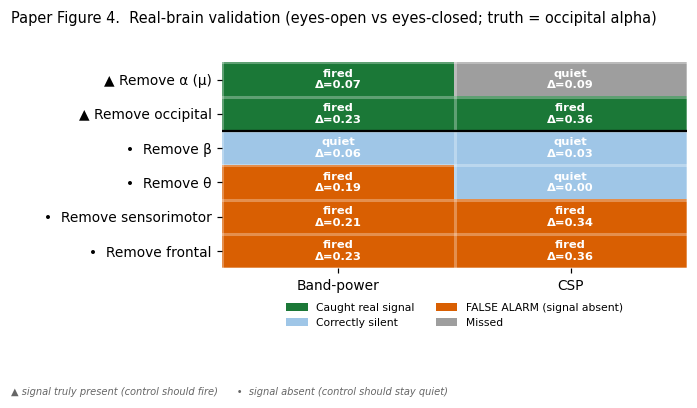

In [21]:
# Real-brain validation results (eyes-open vs eyes-closed on 34 PhysioNet subjects; truth = occipital alpha).
EOEC_CONTROLS = ["Remove α (μ)","Remove occipital","Remove β","Remove θ","Remove sensorimotor","Remove frontal"]
EOEC_TRUTH    = [True, True, False, False, False, False]                 # should the control fire?
EOEC = {"Band-power":{"fire":[1,1,0,1,1,1], "drop":[.07,.23,.06,.19,.21,.23]},
        "CSP":       {"fire":[0,1,0,0,1,1], "drop":[.09,.36,.03,.00,.34,.36]}}
def cell_category(truth, fired):     # 0 caught, 1 correctly-silent, 2 FALSE ALARM, 3 missed
    return 0 if (truth and fired) else (2 if (not truth and fired) else (3 if (truth and not fired) else 1))
CC = ["#1B7837","#9FC6E7","#D95F02","#9E9E9E"]   # caught / correctly-silent / false-alarm / missed
CLABEL = ["Caught real signal","Correctly silent","FALSE ALARM (signal absent)","Missed"]
cols = list(EOEC)
M = np.array([[cell_category(EOEC_TRUTH[i], EOEC[c]["fire"][i]) for c in cols] for i in range(len(EOEC_CONTROLS))])
fig, ax = plt.subplots(figsize=(6.4,3.6)); fig.subplots_adjust(left=.32, bottom=.34, top=.86, right=.98)
ax.imshow(M, cmap=ListedColormap(CC), vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_yticks(range(len(EOEC_CONTROLS)))
ax.set_yticklabels([("▲ " if EOEC_TRUTH[i] else "•  ")+EOEC_CONTROLS[i] for i in range(len(EOEC_CONTROLS))])
ax.set_xticks(np.arange(-.5,len(cols)),minor=True); ax.set_yticks(np.arange(-.5,len(EOEC_CONTROLS)),minor=True)
ax.grid(which="minor",color="white",lw=2); ax.tick_params(which="minor",length=0)
ax.axhline(1.5, color="k", lw=1.5)   # above: signal truly present · below: signal absent
for i in range(len(EOEC_CONTROLS)):
    for j,c in enumerate(cols):
        ax.text(j, i, f"{'fired' if EOEC[c]['fire'][i] else 'quiet'}\nΔ={EOEC[c]['drop'][i]:.2f}",
                ha="center", va="center", color="white", fontsize=7.5, fontweight="bold")
for s in ax.spines.values(): s.set_visible(False)
ax.legend(handles=[Patch(facecolor=CC[k],label=CLABEL[k]) for k in [0,1,2,3]],
          loc="upper center", bbox_to_anchor=(.5,-.12), ncol=2, frameon=False, fontsize=7)
fig.text(.02,.02,"▲ signal truly present (control should fire)      •  signal absent (control should stay quiet)",
         fontsize=6.5, style="italic", color="#666")
fig.suptitle("Paper Figure 4.  Real-brain validation (eyes-open vs eyes-closed; truth = occipital alpha)", x=.02, y=.99, ha="left", fontsize=9.5)
save_paper(fig,"figure4_realbrain_validation"); plt.show()

**The simulator's warning holds on real brains.** Band-power *caught* the real occipital-alpha signal — but
it also **false-alarmed on 3 of 4 unrelated controls**, "detecting" sensorimotor, theta, and frontal
dependence that is simply not there (the signal is occipital). CSP false-alarmed on both spatial controls.
This is the **same specificity failure the simulator predicted — now confirmed on real human EEG.** It is the
sim→real bridge: the instrument's caution is not a simulation artifact, and a bare "the control fired" really
is unreliable evidence for the simple decoders on real brains.

## 20. Limitations and what comes next

- **Simulated ground truth is phenomenological, not a real cortex.** How fully the measured reliabilities
  transfer to real brains is itself an open question (the honest crux, stated in Section 18).
- **Robustness.** Each condition currently uses one simulated dataset draw; repeating across many draws
  would put error bars on the reliability numbers.
- **Scope.** Two older datasets, two-class motor imagery, scalp EEG — no cortical-causality claims.
- **Real-brain confirmation so far covers band/region controls on the alpha task** (Section 19); extending
  it to the motor-imagery decoders themselves needs the known-shortcut injection test.
- **Next:** (1) the known-shortcut confirmation on the MI task; (2) multi-draw robustness for error bars;
  (3) an SSVEP validation (stimulus-imposed ground truth); (4) more decoders and tasks.

Even so, the core deliverable stands on its own: **a validated instrument that tells you how much to
trust each perturbation control — and shows that the answer depends on the decoder.**

## 21. Recap, glossary, and things to try

**One-sentence summary.** Scientists "prove" a brain-reading AI uses the brain by damaging the input
and watching accuracy drop — but we showed those tests can *cry wolf*, and whether you can trust them
depends on the AI, so the tests themselves need to be checked first.

**Glossary**
- **EEG** — recording brain electrical activity from the scalp.
- **Channel / electrode** — one sensor at one spot on the head.
- **Trial** — one short recording while the person imagines a hand.
- **mu rhythm (~10 Hz)** — the motor-cortex wave that changes during hand imagery.
- **Feature** — a number summarizing a trial that the AI looks at.
- **Control / perturbation** — a deliberate damage to the input used to test the AI.
- **Fires** — a control caused a big accuracy drop.
- **False alarm** — a control fired even though its target was absent.

**Try it yourself** (change one thing and re-run):
1. In Section 10, set `strength = 0.3`. Does the weaker signal still get decoded?
2. In Section 5, plant the signal in `OCCIPITAL` instead of motor channels. Which controls fire now?
3. In Section 12, lower `FIRE_THRESHOLD` to `0.05`. Do more controls "fire"? Why is picking a
   threshold tricky?
4. Give the Broad AI only the beta band. Can it still read a signal that lives in mu?

**Honest limitation.** Everything here (and much of the real study) was measured on a *simulated*
brain. Real brains are more complicated, so how well these trust-scores carry over to every real
situation is itself an open research question — which is exactly the kind of honesty good science
requires.